# Diabetes Prediction Using Machine Learning Techniques based on the Pima Indians Diabetes Dataset

## Objective: 
#### To develop and evaluate a machine learning-based predictive model for accurately identifying whether a patient is diabetic or not based on medical diagnostic features

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")   # hide non-critical warnings
import shap

In [2]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ( accuracy_score, precision_score, precision_recall_curve, brier_score_loss, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score, RocCurveDisplay )
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

In [4]:
# A fixed "random seed" means results are the same every run
SEED = 42
np.random.seed(SEED)
 
# --- Colour palette for charts ---
COLORS = ["#185FA5", "#E24B4A", "#3B6D11", "#BA7517", "#7B3FB5", "#0F6E56"]

#### Note - 1
In the above section, we import all the necessary Python libraries that are required for the project.

(i) Pandas and numpy are used for handling data

(ii) Matplotlib and Seaborn are used for the purpose of visualization

(iii) scikit-learn is used for the building and evaluation of ML models

(iv) xgboost, lightgbm and catboost are advanced ML models

(v) Shap is used to explain the model predictions


### Load the Dataset

In [5]:
df = pd.read_csv("diabetes.csv")

In [6]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
print("Shape of the dataset is given by :",df.shape)

Shape of the dataset is given by : (768, 9)


### Note - 2
Load the dataset named "Pima Indians Diabetes dataset."
The column named "Outcome" is the target column.

In [8]:
df['Outcome'].nunique()

2

In [9]:
df['Outcome'].unique()

array([1, 0])

#### Explanation

Outcome = 0 implies that patient is non-diabetic.

Outcome = 1 implies that patient is diabetic.

### Understanding the uploaded dataset

In [10]:
print("\n" + "="*60)
print("          DATASET INFORMATION")
print("="*60 + "\n")

df.info()


          DATASET INFORMATION

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [11]:
print("\n" + "="*60)
print("          Statistical Summary")
print("="*60 + "\n")

df.describe()


          Statistical Summary



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [12]:
print("\n" + "="*60)
print("\n  Statistical Summary (mean, min, max etc.):")
print("\n" + "="*60)
print(df.describe().round(2).to_string())
 



  Statistical Summary (mean, min, max etc.):

       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  DiabetesPedigreeFunction     Age  Outcome
count       768.00   768.00         768.00         768.00   768.00  768.00                    768.00  768.00   768.00
mean          3.85   120.89          69.11          20.54    79.80   31.99                      0.47   33.24     0.35
std           3.37    31.97          19.36          15.95   115.24    7.88                      0.33   11.76     0.48
min           0.00     0.00           0.00           0.00     0.00    0.00                      0.08   21.00     0.00
25%           1.00    99.00          62.00           0.00     0.00   27.30                      0.24   24.00     0.00
50%           3.00   117.00          72.00          23.00    30.50   32.00                      0.37   29.00     0.00
75%           6.00   140.25          80.00          32.00   127.25   36.60                      0.63   41.00     1.00
max     

In [13]:
# Missing Value Check
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [14]:
# Duplicate Check
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [15]:
outcome_counts = df['Outcome'].value_counts()
print("Total number of diabetic cases are :", outcome_counts[1])
print("Total number of non-diabetic cases are :", outcome_counts[0])

Total number of diabetic cases are : 268
Total number of non-diabetic cases are : 500


### Note - 3

##### The above steps help us to understand the structure of the dataset.
##### dataset contains the following medical features:
Pregnancies 

Glucose   

Blood Pressure

Skin Thickness

Insulin

BMI 

DiabetesPedigreeFunction

Age    

Outcome  


### Check Class imbalance Visualization:

In [16]:
columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns:
    print(col, ":", (df[col] == 0).sum())

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


In [17]:
print("Sum of zeros in Insulin column : ",(df['Insulin']==0).sum())

Sum of zeros in Insulin column :  374


In [18]:
# ─── Step 2: How many diabetic vs non-diabetic? ───────────
counts    = df['Outcome'].value_counts()
percents  = df['Outcome'].value_counts(normalize=True) * 100
 
print(f"\n Class Distribution:")
print(f"   Non-Diabetic (0) : {counts[0]} patients  ({percents[0]:.1f}%)")
print(f"   Diabetic     (1) : {counts[1]} patients  ({percents[1]:.1f}%)")
print(f"Class imbalance: more non-diabetic than diabetic patients")


 Class Distribution:
   Non-Diabetic (0) : 500 patients  (65.1%)
   Diabetic     (1) : 268 patients  (34.9%)
Class imbalance: more non-diabetic than diabetic patients


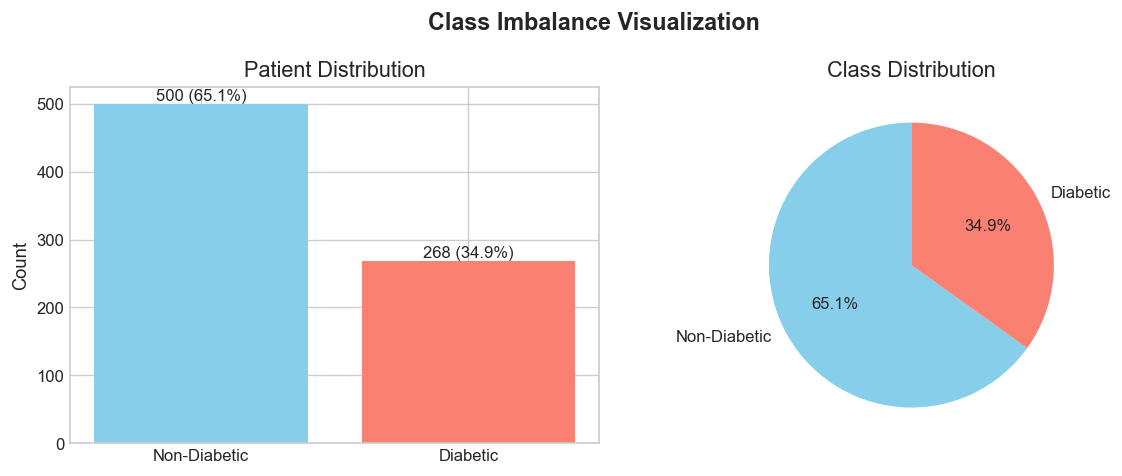

In [19]:
COLORS = ['skyblue', 'salmon']

# Create Figure with 2 plots

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# For bar chart 
bars = axes[0].bar(
    ['Non-Diabetic', 'Diabetic'],
    counts.values,
    color=COLORS
)

# Total samples
total = counts.sum()

# Add count and percentage labels
for bar in bars:
    
    height = bar.get_height()
    percentage = (height / total) * 100
    
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        f'{int(height)} ({percentage:.1f}%)',
        ha='center',
        fontsize=10
    )

# Bar chart title and labels
axes[0].set_title('Patient Distribution')
axes[0].set_ylabel('Count')

# For Pie Chart

axes[1].pie(
    counts.values,
    labels=['Non-Diabetic', 'Diabetic'],
    colors=COLORS,
    autopct='%1.1f%%',
    startangle=90
)

# Pie chart title
axes[1].set_title('Class Distribution')

# MAIN TITLE
plt.suptitle(
    'Class Imbalance Visualization',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

### Class Distribution Analysis Using Count Plot

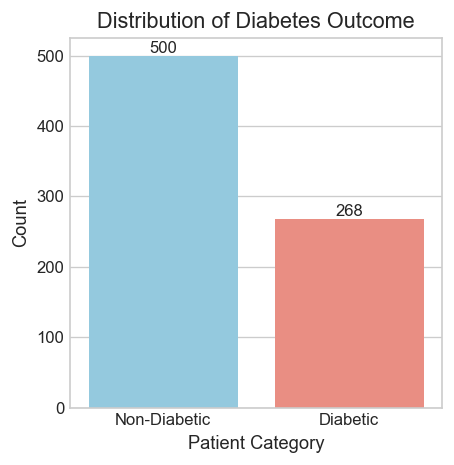

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
plt.figure(figsize=(4, 4))

# Count plot
ax = sns.countplot(
    data=df,
    x='Outcome',
    palette=['skyblue', 'salmon']
)

# Change labels
ax.set_xticklabels(['Non-Diabetic', 'Diabetic'])

# Add count labels
for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

# Titles and labels
plt.title('Distribution of Diabetes Outcome')
plt.xlabel('Patient Category')
plt.ylabel('Count')

plt.show()

#### Note - 4
The above illustrated graphs are very important to easily understand whether the dataset is balanced or not. Especially in the field of medical prediction projects, imbalance of the class is significant because these models cam correctly identify diabetic patients.

### Identify Invalid zero values in the dataset

In [21]:
ZERO_COLS = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
 
print("\n Zero-Value Anomaly Analysis:")
print("(Zeros in these columns mean MISSING data, not true zeros)\n")


 Zero-Value Anomaly Analysis:
(Zeros in these columns mean MISSING data, not true zeros)



In [22]:
zero_info = pd.DataFrame({
    "Column"       : ZERO_COLS,
    "Zero Count"   : [(df[c] == 0).sum() for c in ZERO_COLS],
    "Zero %"       : [f"{(df[c] == 0).mean()*100:.1f}%" for c in ZERO_COLS],
    "Why it matters": [
        "Glucose = 0 is biologically impossible",
        "BP = 0 means the patient is dead",
        "Skin thickness = 0 was simply not recorded",
        " Insulin = 0 is the most missing (374 zeros)",
        "BMI = 0 is physically impossible"
    ]
})
 

In [23]:
print(zero_info.to_string(index=False))

       Column  Zero Count Zero %                               Why it matters
      Glucose           5   0.7%       Glucose = 0 is biologically impossible
BloodPressure          35   4.6%             BP = 0 means the patient is dead
SkinThickness         227  29.6%   Skin thickness = 0 was simply not recorded
      Insulin         374  48.7%  Insulin = 0 is the most missing (374 zeros)
          BMI          11   1.4%             BMI = 0 is physically impossible


<function matplotlib.pyplot.show(close=None, block=None)>

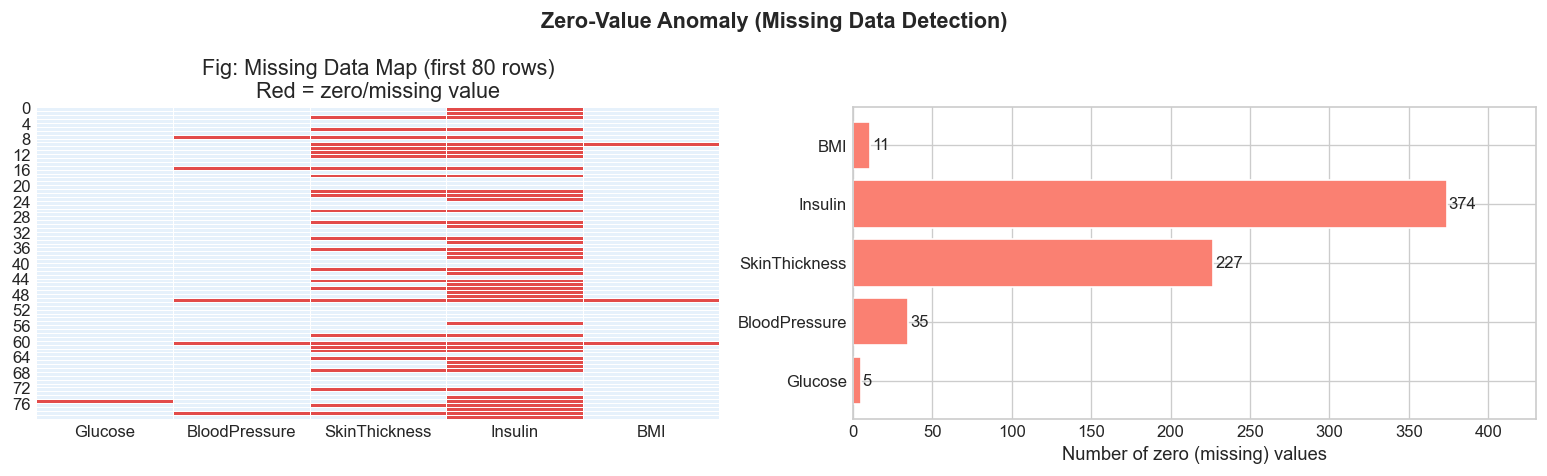

In [24]:
#Zero count bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
 
# Heatmap of missing values (zeros shown as red)
zero_flags = (df[ZERO_COLS] == 0).astype(int).head(80)
sns.heatmap(zero_flags, cmap=["#E6F1FB", "#E24B4A"],
            cbar=False, linewidths=0.4, ax=axes[0])
axes[0].set_title("Fig: Missing Data Map (first 80 rows)\nRed = zero/missing value")

# Bar chart of zero counts
zero_counts = (df[ZERO_COLS] == 0).sum()
axes[1].barh(zero_counts.index, zero_counts.values,
             color=COLORS[1], edgecolor="white")
for i, val in enumerate(zero_counts.values):
    axes[1].text(val + 1, i, str(val), va="center", fontsize=10)
axes[1].set_xlabel("Number of zero (missing) values")
axes[1].set_xlim(0, 430)
 
plt.suptitle("Zero-Value Anomaly (Missing Data Detection)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show

#### Note - 5 have to edit

This code visually identifies and analyzes medically invalid zero values in important health-related features of the diabetes dataset. The heatmap helps detect patterns of missing data across patient records, while the horizontal bar chart summarizes the total number of zero values present in each column. These visualizations help understand data quality issues and justify preprocessing steps such as missing value imputation before building machine learning models.

In [25]:

zero_percent = ((df[ZERO_COLS] == 0).mean() * 100).round(1)

In [26]:
FEATURES = [
    "Pregnancies",           
    "Glucose",               
    "BloodPressure",         
    "SkinThickness",         
    "Insulin",               
    "BMI",                   # Body Mass Index
    "DiabetesPedigreeFunction",  # Genetic diabetes risk score
    "Age"                    
]
TARGET = "Outcome" 

#### Data Imputation Analysis

In [27]:
# Replace zeros with NaN (proper missing value) 
df_imputation = df.copy()
df_imputation[ZERO_COLS] = df_imputation[ZERO_COLS].replace(0, np.nan)

In [28]:
X_imp = df_imputation[FEATURES].values
y_imp = df_imputation[TARGET].values

In [29]:
# Define 3 imputation methods
imputers = {
    "Mean": SimpleImputer(strategy="mean"),
    "KNN (k=5)": KNNImputer(n_neighbors=5),
    "MICE": IterativeImputer(random_state=SEED, max_iter=10)
}

In [30]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
probe_model = RandomForestClassifier(n_estimators=100, random_state=SEED)

imp_results = {}

print("\n Testing each imputation strategy.\n")

for method_name, imputer in imputers.items():
    
    fold_aucs = []

    for train_idx, val_idx in skf.split(X_imp, y_imp):

# Split training and validation data
        X_train_fold, X_val_fold = X_imp[train_idx], X_imp[val_idx]
        y_train_fold, y_val_fold = y_imp[train_idx], y_imp[val_idx]

# Fit imputer only on training data
        imp_fitted = imputer.__class__(**imputer.get_params())

        X_train_imp = imp_fitted.fit_transform(X_train_fold)
        X_val_imp   = imp_fitted.transform(X_val_fold)

# Train model
        probe_model.fit(X_train_imp, y_train_fold)

# Predict probabilities and calculate AUC
        prob = probe_model.predict_proba(X_val_imp)[:, 1]
        auc = roc_auc_score(y_val_fold, prob)

        fold_aucs.append(auc)
# Store results
    avg_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)

    imp_results[method_name] = {
        "avg_auc": avg_auc,
        "std_auc": std_auc,
        "fold_aucs": fold_aucs
    }

    print(f"{method_name:12s} → AUC = {avg_auc:.4f} (±{std_auc:.4f})")


 Testing each imputation strategy.

Mean         → AUC = 0.8231 (±0.0193)
KNN (k=5)    → AUC = 0.8321 (±0.0190)
MICE         → AUC = 0.8277 (±0.0120)


In [31]:
# Find out the best imputation method
best_method = max(
    imp_results,
    key=lambda k: imp_results[k]["avg_auc"]
)

# Best model AUC
best_auc = imp_results[best_method]["avg_auc"]

# Mean imputation AUC
mean_auc = imp_results["Mean"]["avg_auc"]

# Percentage improvement
improvement = ((best_auc - mean_auc) / mean_auc) * 100

# Display results
print(f"\n WINNER : {best_method}")
print(f"   AUC = {best_auc:.4f}")
print(f"   Improvement over Mean: +{improvement:.1f}%")


 WINNER : KNN (k=5)
   AUC = 0.8321
   Improvement over Mean: +1.1%


#### Model Performance Comparison Across Different Imputation Strategies

In [32]:
# --- Colour palette for charts ---
COLORS = ["#185FA5", "#E24B4A", "#3B6D11", "#BA7517", "#7B3FB5", "#0F6E56"]

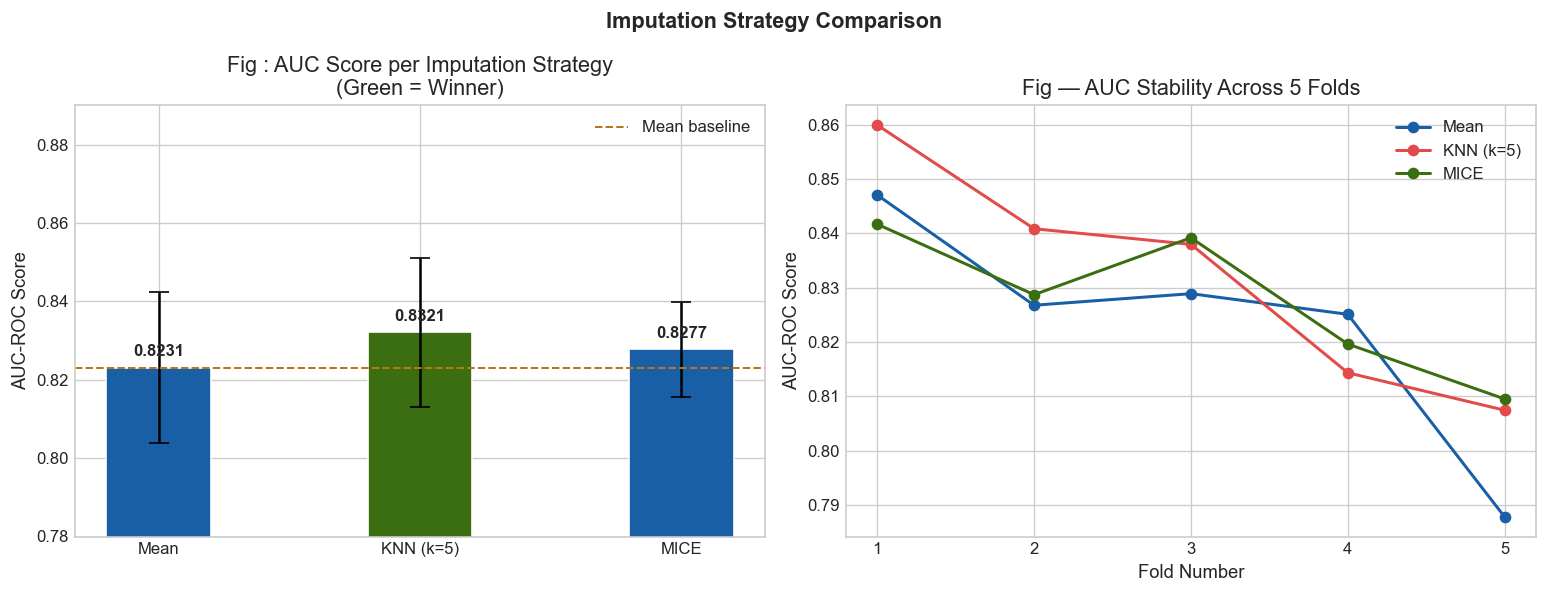

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Data for plots
methods = list(imp_results.keys())
means = [imp_results[m]["avg_auc"] for m in methods]
stds = [imp_results[m]["std_auc"] for m in methods]

# Highlight best method
bar_colors = [
    COLORS[2] if m == best_method else COLORS[0]
    for m in methods
]

# Left Plot → Bar Chart

bars = axes[0].bar(
    methods,
    means,
    yerr=stds,
    color=bar_colors,
    capsize=6,
    width=0.4,
    edgecolor="white"
)

# Add value labels
for bar, val in zip(bars, means):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.003,
        f"{val:.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

axes[0].set_ylim(0.78, 0.89)
axes[0].set_title(
    "Fig : AUC Score per Imputation Strategy\n(Green = Winner)"
)
axes[0].set_ylabel("AUC-ROC Score")

# Baseline line
axes[0].axhline(
    mean_auc,
    color=COLORS[3],
    linestyle="--",
    linewidth=1.2,
    label="Mean baseline"
)

axes[0].legend()

# Right Plot → Fold Stability

for i, (method, res) in enumerate(imp_results.items()):

    axes[1].plot(
        range(1, 6),
        res["fold_aucs"],
        marker="o",
        linewidth=1.8,
        color=COLORS[i],
        label=method
    )

axes[1].set_title("Fig — AUC Stability Across 5 Folds")
axes[1].set_xlabel("Fold Number")
axes[1].set_ylabel("AUC-ROC Score")
axes[1].set_xticks(range(1, 6))
axes[1].legend()

# Main title
plt.suptitle(
    "Imputation Strategy Comparison",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [34]:
df_clean = df.copy()
df_clean[ZERO_COLS] = df_clean[ZERO_COLS].replace(0, np.nan)

In [35]:
## Applying KNN imputation to the full dataset:
from sklearn.impute import KNNImputer

# Best imputation method
knn_imputer = KNNImputer(n_neighbors=5)

df_clean[FEATURES] = knn_imputer.fit_transform(df_clean[FEATURES])

In [36]:
(df_clean['BloodPressure']==0).sum()

np.int64(0)

### Visualization for how each medical features behaves for Diabetic and Non-diabetic

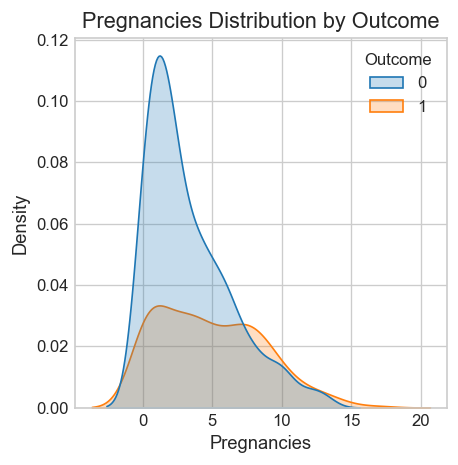

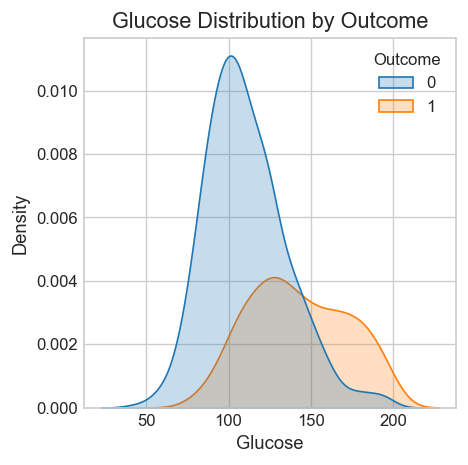

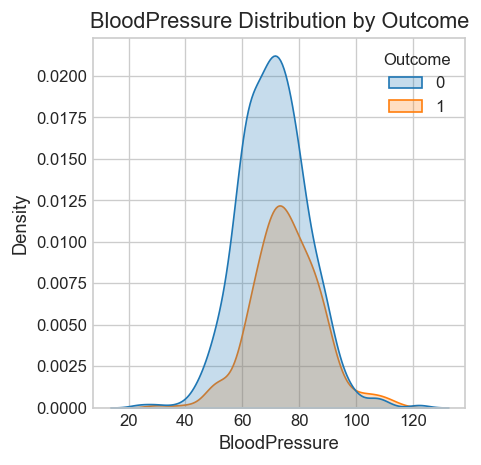

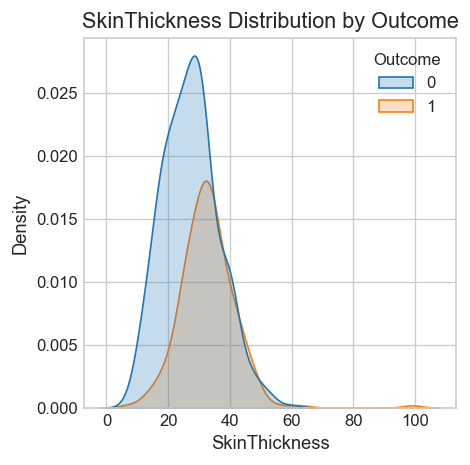

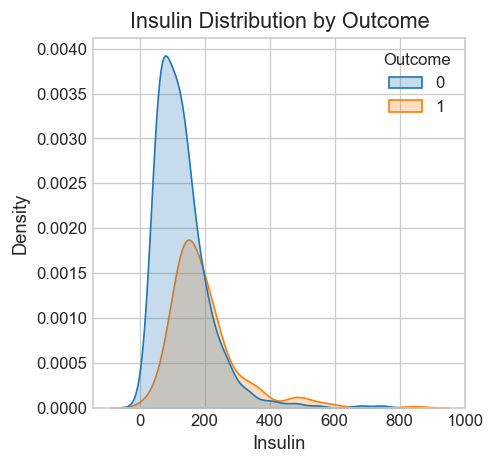

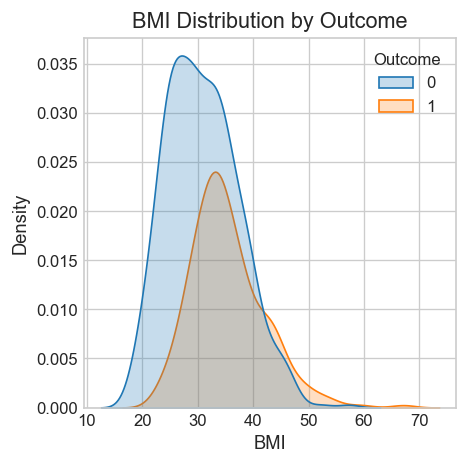

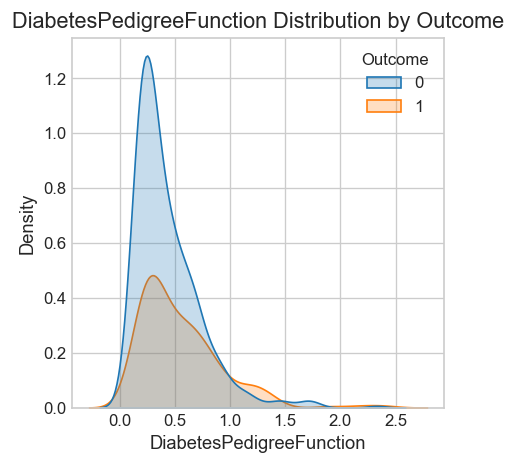

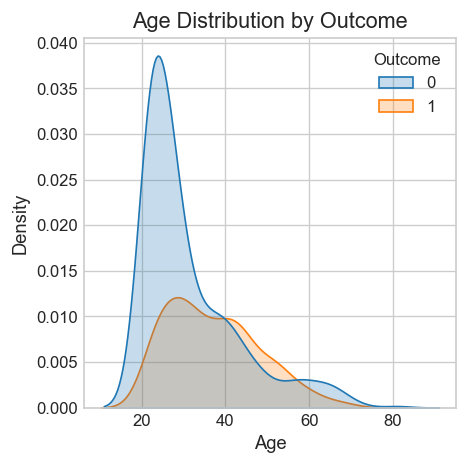

In [37]:
for col in FEATURES:

    plt.figure(figsize=(4, 4))

    sns.kdeplot(
        data=df_clean,
        x=col,
        hue="Outcome",
        fill=True
    )

    plt.title(f"{col} Distribution by Outcome")
    plt.xlabel(col)
    plt.ylabel("Density")

    plt.show()

In [38]:
print(f"    Remaining missing values: {df_clean.isnull().sum().sum()}  (should be 0)")
print(f"    Dataset shape: {df_clean.shape}")

    Remaining missing values: 0  (should be 0)
    Dataset shape: (768, 9)


##### Correlation Heatmap after KNN imputation

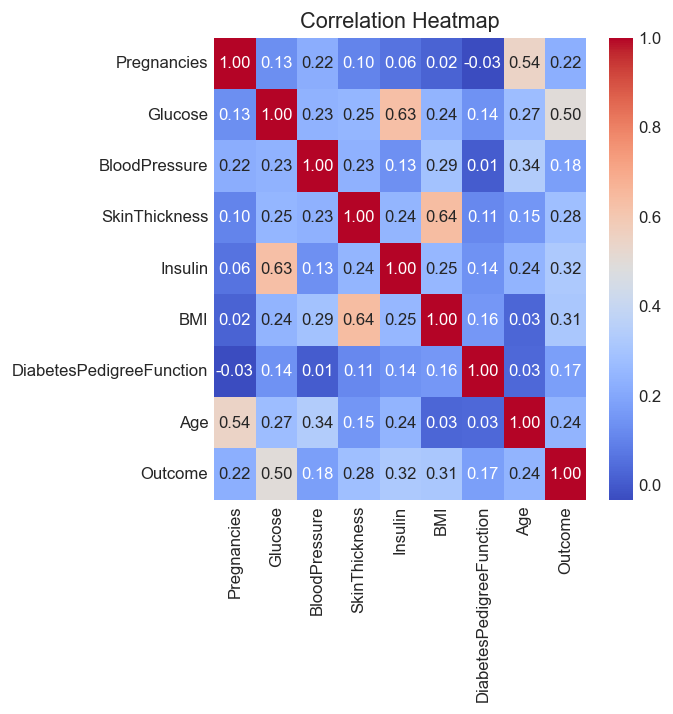

In [39]:
plt.figure(figsize=(5,5))

sns.heatmap(
    df_clean.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Feature Engineering:

##### Boxplot for outlier analysis

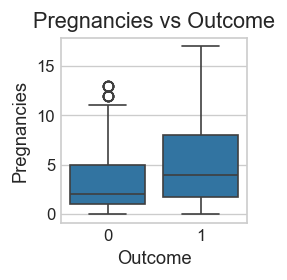

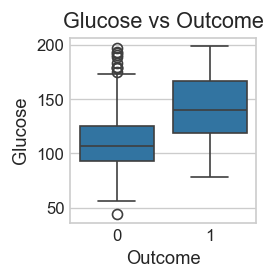

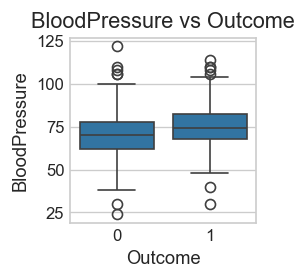

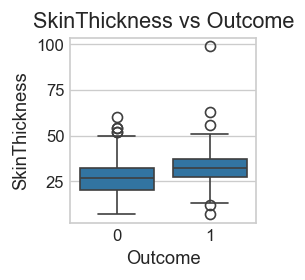

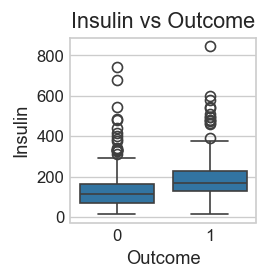

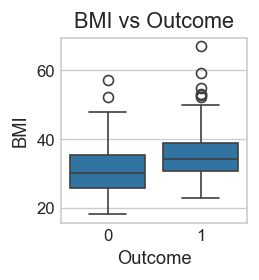

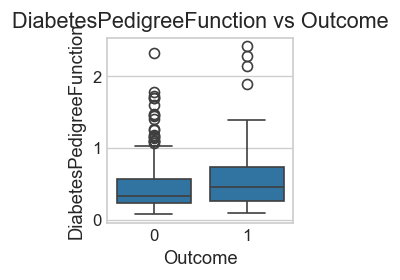

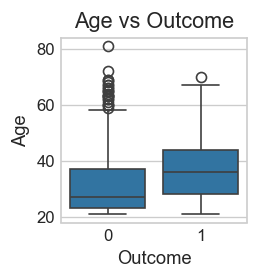

In [40]:
for col in FEATURES:

    plt.figure(figsize=(2, 2))

    sns.boxplot(
        data=df_clean,
        x="Outcome",
        y=col
    )

    plt.title(f"{col} vs Outcome")
    plt.xlabel("Outcome")
    plt.ylabel(col)

    plt.show()

In [41]:
def treat_outliers(column):
    
    q1    = column.quantile(0.25)   
    q3    = column.quantile(0.75)   
    iqr   = q3 - q1                 
    lower = q1 - 1.5 * iqr         
    upper = q3 + 1.5 * iqr         
    return column.clip(lower=lower, upper=upper)

In [42]:
df_feature = df_clean.copy()
 

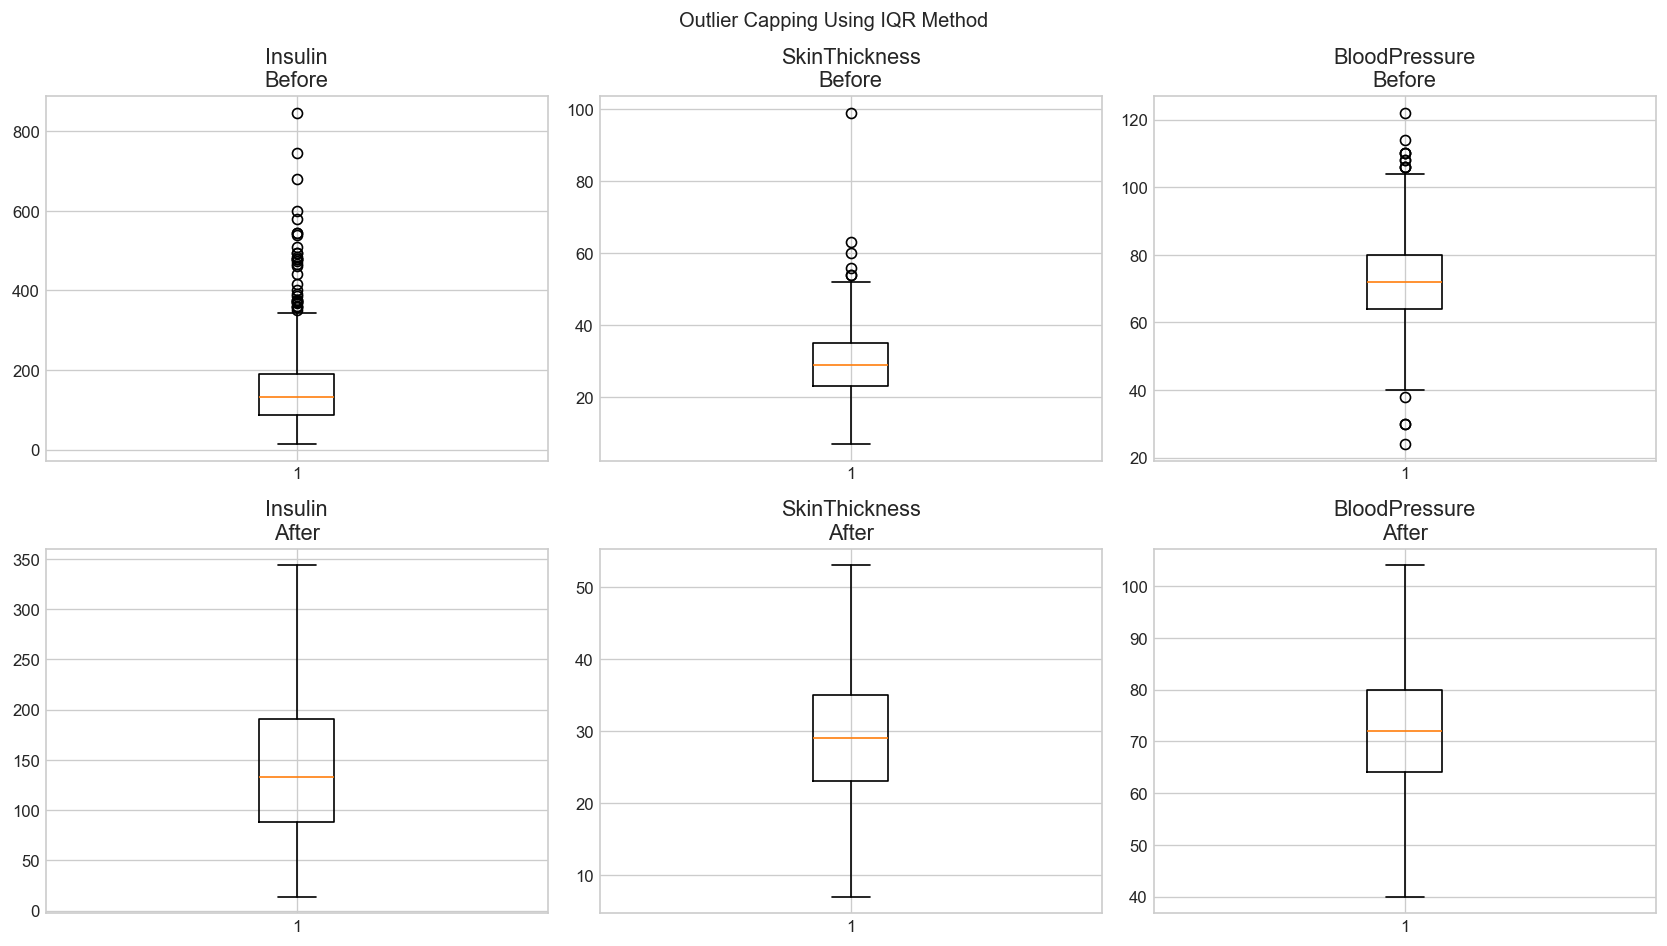

In [43]:
# Columns for outlier treatment
OUTLIER_COLS = ["Insulin", "SkinThickness", "BloodPressure"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(OUTLIER_COLS):

    # Before capping
    axes[0, i].boxplot(df_feature[col].dropna())
    axes[0, i].set_title(f"{col}\nBefore")

    # Apply capping
    df_feature[col] = treat_outliers(df_feature[col])

    # After capping
    axes[1, i].boxplot(df_feature[col].dropna())
    axes[1, i].set_title(f"{col}\nAfter")

# Main title
plt.suptitle("Outlier Capping Using IQR Method")

plt.tight_layout()
plt.show()

###### Creation of two new features for the better prediction:

In [44]:
df_feature["BMI_Age_Interaction"] = df_feature["BMI"] * df_feature["Age"]

In [45]:
df_feature["Glucose_Insulin_Ratio"] = df_feature["Glucose"] / (df_feature["Insulin"] + 1)

In [46]:
NEW_FEATURES = ["BMI_Age_Interaction", "Glucose_Insulin_Ratio"]

In [47]:
COMPLETE_FEATURES = FEATURES + NEW_FEATURES

In [48]:
print("Total number of features are given by :",len(COMPLETE_FEATURES))

Total number of features are given by : 10


##### Find out  the new features correlation with the outcome

In [49]:
# Correlation of new features with target
new_corr = df_feature[NEW_FEATURES + [TARGET]].corr()[TARGET].drop(TARGET)

print("\n New Feature Correlation with Outcome:\n")

for feat, val in new_corr.items():
    print(f"{feat:25s}: {val:.3f}")



 New Feature Correlation with Outcome:

BMI_Age_Interaction      : 0.363
Glucose_Insulin_Ratio    : -0.133


###### Correlation Heatmap after KNN Imputation

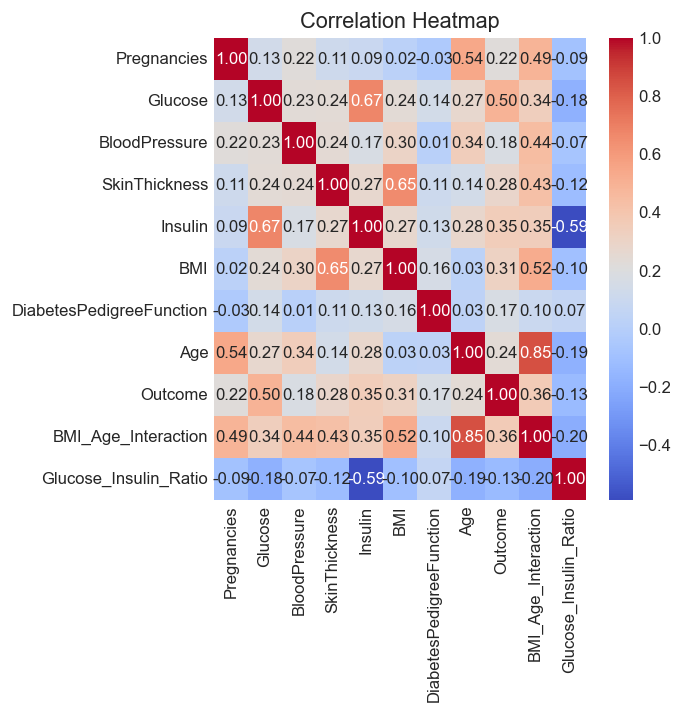

In [50]:
plt.figure(figsize=(5,5))

sns.heatmap(
    df_feature.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

##### Evaluating feature importance for the Prediction

In [51]:
# Prepare data
X_probe = df_feature[COMPLETE_FEATURES]
y_probe = df_feature[TARGET]

# Scale data
sc_probe = StandardScaler()
X_sc_prob = sc_probe.fit_transform(X_probe)

# Train Random Forest
rf_imp = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED
)

rf_imp.fit(X_sc_prob, y_probe)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [52]:
## Getting Feature Importance
# Feature importance values
imp_series = pd.Series(
    rf_imp.feature_importances_,
    index=COMPLETE_FEATURES
).sort_values()

# Colors for bars
bc = [
    COLORS[2] if f in NEW_FEATURES else COLORS[0]
    for f in imp_series.index
]

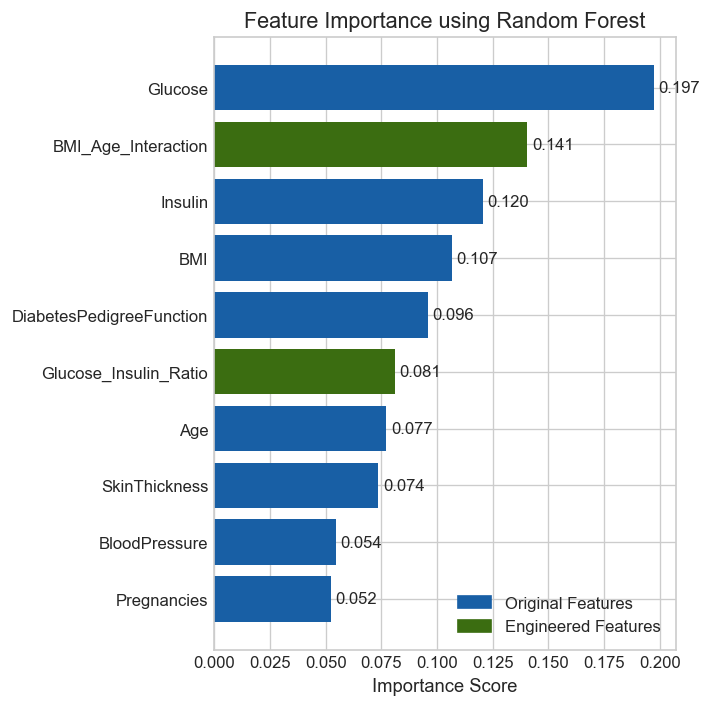

In [53]:
## Plotting barchart for understanding the feature importance:

plt.figure(figsize=(6, 6))

bars = plt.barh(
    imp_series.index,
    imp_series.values,
    color=bc
)

# Add values on bars
for bar in bars:
    plt.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.3f}",
        va="center"
    )

# Labels and title
plt.title("Feature Importance using Random Forest")
plt.xlabel("Importance Score")

# Legend
blue_p = mpatches.Patch(color=COLORS[0], label="Original Features")
green_p = mpatches.Patch(color=COLORS[2], label="Engineered Features")

plt.legend(handles=[blue_p, green_p])

plt.tight_layout()
plt.show()

##### Correlation Heatmap after KNN imputation

##### Smote class balancing:

In [54]:
X_all = df_feature[COMPLETE_FEATURES].values
y_all = df_feature[TARGET].values

In [55]:
## Train - Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.20,
    stratify=y_all,
    random_state=SEED
)

In [56]:
# Train & Test dataset information

print(
    f"\n Train Data : {len(X_train)} patients "
    f"({y_train.mean() * 100:.1f}% diabetic)"
)

print(
    f" Test Data  : {len(X_test)} patients "
    f"({y_test.mean() * 100:.1f}% diabetic)"
)


 Train Data : 614 patients (34.9% diabetic)
 Test Data  : 154 patients (35.1% diabetic)


In [57]:
# Scailing before applying SMOTE:
scaler = StandardScaler()
X_train_sclr = scaler.fit_transform(X_train)
X_test_sclr = scaler.transform(X_test)

In [58]:
before = Counter(y_train)

print("\n    BEFORE SMOTE")
print(f"Non-Diabetic (0): {before[0]}")
print(f"Diabetic (1)    : {before[1]}")


    BEFORE SMOTE
Non-Diabetic (0): 400
Diabetic (1)    : 214


In [59]:
#  Applying SMOTE to training dataset

smote = SMOTE(
    sampling_strategy="minority",
    random_state=SEED
)

X_train_bal, y_train_bal = smote.fit_resample(
    X_train_sclr,
    y_train
)


In [60]:
## Distribution of classes shows after appling SMOTE
after = Counter(y_train_bal)

print("\n    AFTER SMOTE")
print(f"Non-Diabetic (0): {after[0]}")
print(f"Diabetic (1)    : {after[1]}")


    AFTER SMOTE
Non-Diabetic (0): 400
Diabetic (1)    : 400


In [61]:
# Synthetic samples are  created
print(f"\nSynthetic samples created: {after[1] - before[1]}")


Synthetic samples created: 186


In [62]:
# Verifying the test set remains unchanged :
test_c = Counter(y_test)

print("\n  Test Set (Unchanged)")
print(f"Non-Diabetic (0): {test_c[0]}")
print(f"Diabetic (1)    : {test_c[1]}")


  Test Set (Unchanged)
Non-Diabetic (0): 100
Diabetic (1)    : 54


#### Visualization of before and after applying the SMOTE

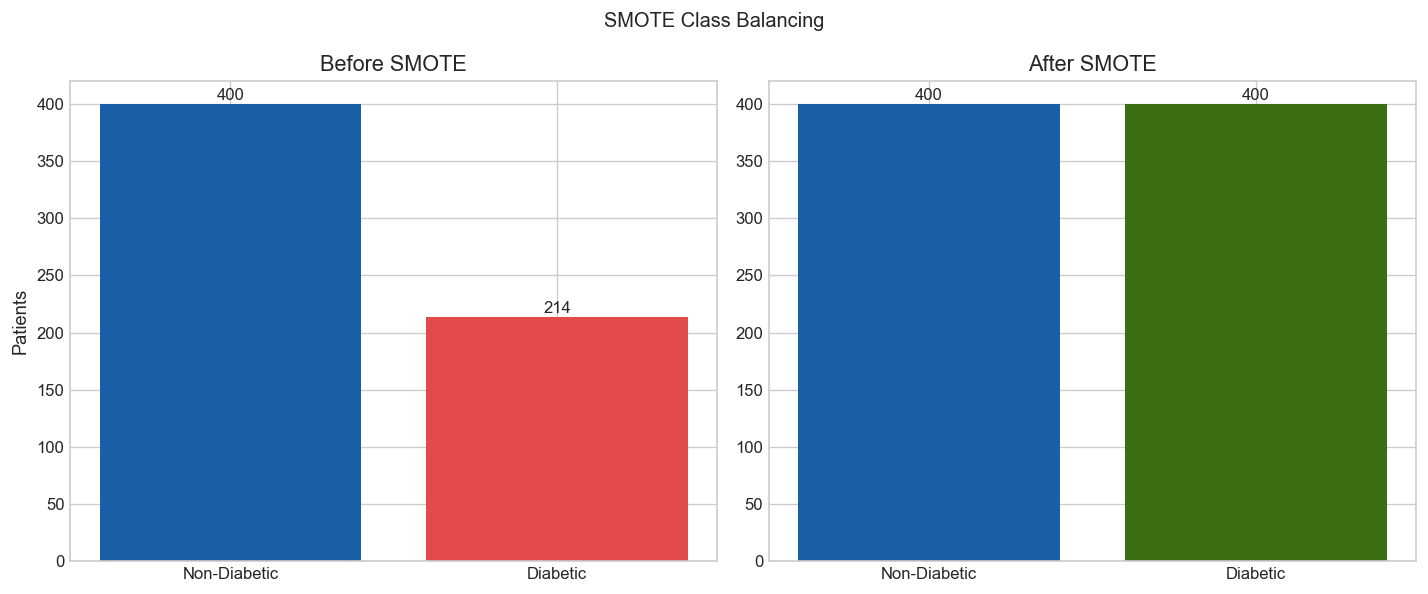

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Before applying SMOTE
axes[0].bar(
    ["Non-Diabetic", "Diabetic"],
    [before[0], before[1]],
    color=[COLORS[0], COLORS[1]]
)

for i, v in enumerate([before[0], before[1]]):
    axes[0].text(i, v + 3, str(v), ha="center")

axes[0].set_title("Before SMOTE")
axes[0].set_ylabel("Patients")

# After applying SMOTE
axes[1].bar(
    ["Non-Diabetic", "Diabetic"],
    [after[0], after[1]],
    color=[COLORS[0], COLORS[2]]
)

for i, v in enumerate([after[0], after[1]]):
    axes[1].text(i, v + 3, str(v), ha="center")

axes[1].set_title("After SMOTE")

plt.suptitle("SMOTE Class Balancing")
plt.tight_layout()
plt.show()

### Stacking Classifier

In [64]:
## Class Imbalance Ratio:

class_ratio = before[0] / before[1]
print(f"\n Class Ratio is given by : {class_ratio:.2f}")



 Class Ratio is given by : 1.87


In [65]:
## Defining Base Models:

base_models = {

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        scale_pos_weight=class_ratio,
        random_state=SEED
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        class_weight="balanced",
        random_state=SEED
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        class_weight="balanced",
        random_state=SEED,
        verbose=-1
    )
}

In [66]:
## Prepare storage for Stacking Prediction:
# Cross-validation:

skf_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

# no: of models and samples
n_base = len(base_models)
n_tr = len(X_train_sclr)

# Storage arrays
oof_train = np.zeros((n_tr, n_base))
oof_test = np.zeros((len(X_test), n_base))

# Store fold AUC scores
oof_aucs = {
    name: [] for name in base_models
}

In [67]:
## Following represents the core stacking process.

print("\nBuilding OOF predictions...\n")

for fold_i, (tr_idx, val_idx) in enumerate(
    skf_cv.split(X_train_sclr, y_train)
):

    # Split fold data
    X_tr_f = X_train_sclr[tr_idx]
    X_val_f = X_train_sclr[val_idx]

    y_tr_f = y_train[tr_idx]
    y_val_f = y_train[val_idx]

    # Apply SMOTE only on training fold
    smote_fold = SMOTE(random_state=SEED)

    X_tr_bal_f, y_tr_bal_f = smote_fold.fit_resample(
        X_tr_f,
        y_tr_f
    )

    # Train each base model
    for b_i, (name, clf) in enumerate(base_models.items()):

        model = clf.__class__(**clf.get_params())

        model.fit(X_tr_bal_f, y_tr_bal_f)

        # Validation predictions
        val_prob = model.predict_proba(X_val_f)[:, 1]

        # Test predictions
        test_prob = model.predict_proba(X_test_sclr)[:, 1]

        # Store predictions
        oof_train[val_idx, b_i] = val_prob
        oof_test[:, b_i] += test_prob / 5

        # Store AUC
        auc = roc_auc_score(y_val_f, val_prob)
        oof_aucs[name].append(auc)

    print(f"Fold {fold_i + 1} Complete")


Building OOF predictions...

Fold 1 Complete
Fold 2 Complete
Fold 3 Complete
Fold 4 Complete
Fold 5 Complete


In [68]:
## Training the meta learner:

# Train meta-learner

meta_clf = LogisticRegression(
    class_weight="balanced",
    random_state=SEED,
    max_iter=1000
)

meta_clf.fit(oof_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [69]:
## Final of Stacking Predictions:

stack_probs = meta_clf.predict_proba(oof_test)[:, 1]

stack_preds = (stack_probs >= 0.5).astype(int)

stack_auc = roc_auc_score(y_test, stack_probs)

print(f"\n Stacking AUC : {stack_auc:.4f}")


 Stacking AUC : 0.8270


#### Evaluation of models:

In [70]:
## Training each models

all_models = {

    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        random_state=SEED
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=SEED
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=SEED
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        scale_pos_weight=class_ratio,
        random_state=SEED
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=SEED,
        verbose=-1
    )
}

In [71]:
# Train the models and stores the result

# Store results

results = {}

trained_models = {}

print("\nTraining Models...\n")

for mname, model in all_models.items():

    # Train model
    model.fit(X_train_bal, y_train_bal)

    # Predict probabilities
    y_prob = model.predict_proba(X_test_sclr)[:, 1]

    # Final predictions
    y_pred = (y_prob >= 0.5).astype(int)

    # Store results
    results[mname] = {

        "Accuracy": accuracy_score(y_test, y_pred),

        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "F1-Score": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "AUC-ROC": roc_auc_score(
            y_test,
            y_prob
        ),

        # IMPORTANT FOR CALIBRATION
        "Brier": brier_score_loss(
            y_test,
            y_prob
        ),

        # IMPORTANT FOR ROC CURVE
        "y_prob": y_prob,

        # IMPORTANT FOR CONFUSION MATRIX
        "y_pred": y_pred
    }

    trained_models[mname] = model

    print(f"✓ {mname}")


Training Models...

✓ Logistic Regression
✓ SVM
✓ Random Forest
✓ XGBoost
✓ LightGBM


In [72]:
## Adding the stack classifier results:

# Add stacking classifier

results["Stacking Classifier"] = {

    "Accuracy": accuracy_score(
        y_test,
        stack_preds
    ),

    "Precision": precision_score(
        y_test,
        stack_preds,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        stack_preds,
        zero_division=0
    ),

    "F1-Score": f1_score(
        y_test,
        stack_preds,
        zero_division=0
    ),

    "AUC-ROC": stack_auc,

    "Brier": brier_score_loss(
        y_test,
        stack_probs
    ),

    "y_prob": stack_probs,

    "y_pred": stack_preds
}

print("✓ Stacking Classifier")

✓ Stacking Classifier


In [73]:
### Creation of model comparison table:

# Create comparison table

comp_df = pd.DataFrame([

    {
        "Model": n,

        "Accuracy": round(v["Accuracy"], 4),

        "Precision": round(v["Precision"], 4),

        "Recall": round(v["Recall"], 4),

        "F1-Score": round(v["F1-Score"], 4),

        "AUC-ROC": round(v["AUC-ROC"], 4),

        "Brier": round(v["Brier"], 4)
    }

    for n, v in results.items()
])

print(comp_df)

                 Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC   Brier
0  Logistic Regression    0.7078     0.5763  0.6296    0.6018   0.7944  0.1877
1                  SVM    0.7208     0.6000  0.6111    0.6055   0.7906  0.1854
2        Random Forest    0.7403     0.6167  0.6852    0.6491   0.8266  0.1641
3              XGBoost    0.7662     0.6552  0.7037    0.6786   0.8081  0.2085
4             LightGBM    0.7338     0.6102  0.6667    0.6372   0.8078  0.2154
5  Stacking Classifier    0.7338     0.5915  0.7778    0.6720   0.8270  0.1724


In [74]:
results[mname] = {

    "Accuracy": accuracy_score(y_test, y_pred),

    "Precision": precision_score(y_test, y_pred),

    "Recall": recall_score(y_test, y_pred),

    "F1-Score": f1_score(y_test, y_pred),

    "AUC-ROC": roc_auc_score(y_test, y_prob),

    "Brier": brier_score_loss(y_test, y_prob),

    "y_prob": y_prob,

    "y_pred": y_pred
}

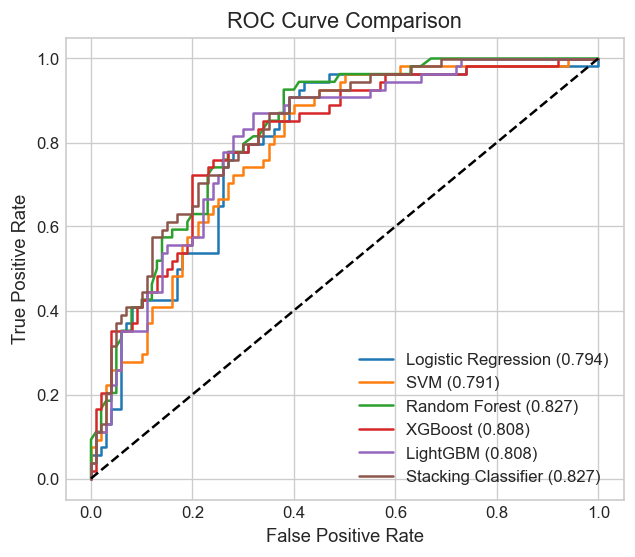

In [75]:
## Visualization of ROC Curve

# ROC Curve comparison

plt.figure(figsize=(6, 5))

for n, res in results.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        res["y_prob"]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{n} ({res['AUC-ROC']:.3f})"
    )

# Random baseline
plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

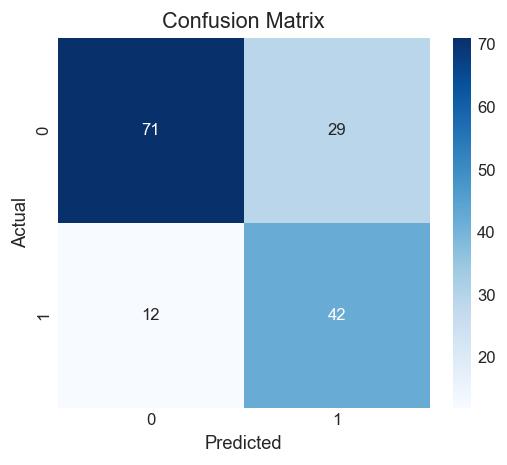

In [76]:
## Confusion Matrix
cm = confusion_matrix(
    y_test,
    results["Stacking Classifier"]["y_pred"]
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

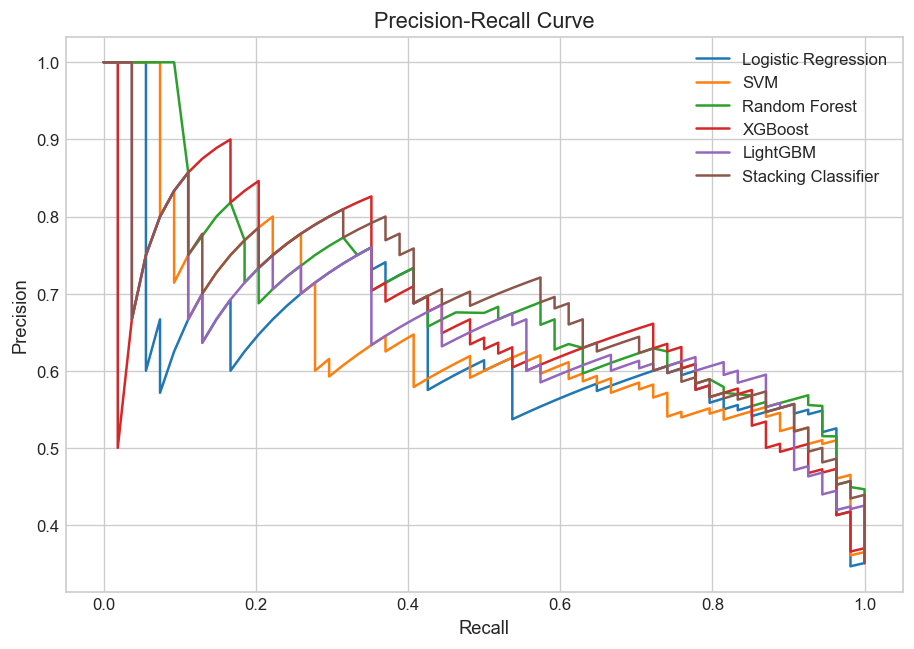

In [77]:
## Precison - Recall Curve:

plt.figure(figsize=(9, 6))
for n, res in results.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        res["y_prob"]
    )

    plt.plot(
        recall,
        precision,
        label=n
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

#### SHAP EXPLAINABILITY:

In [78]:
# Select trained XGBoost model

xgb_model = trained_models["XGBoost"]

print("\nComputing SHAP values...")

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Convert test data into dataframe
X_test_df = pd.DataFrame(
    X_test_sclr,
    columns=COMPLETE_FEATURES
)



Computing SHAP values...


In [79]:
# Generate SHAP values
shap_values = explainer.shap_values(X_test_df)

print("SHAP values computed successfully!")

print(f"Shape : {shap_values.shape}")

print(f"Base Value : {explainer.expected_value:.4f}")

SHAP values computed successfully!
Shape : (154, 10)
Base Value : 0.7139


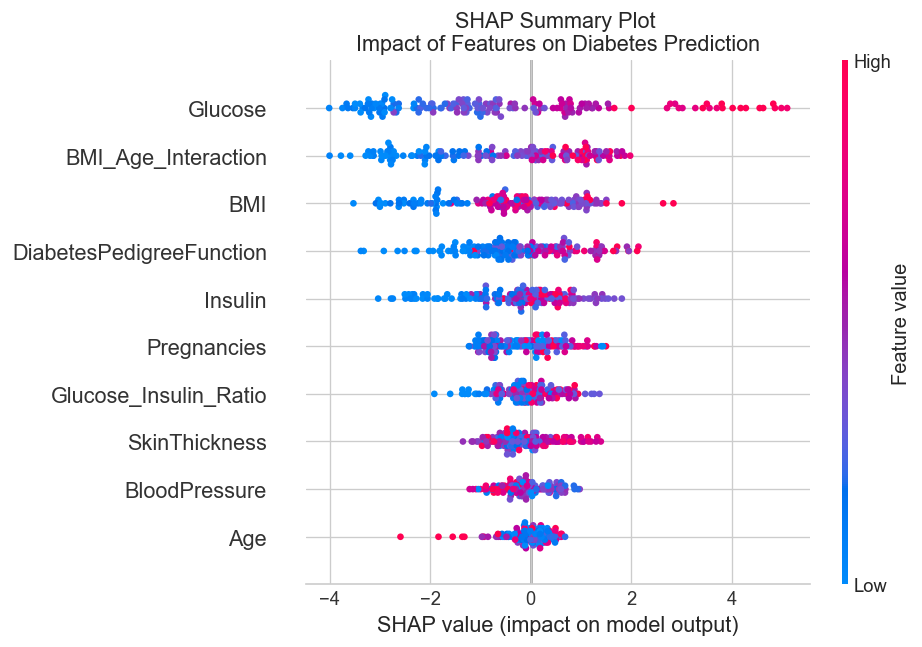

In [80]:
##SHAP Summary Beeswarm Plot

plt.figure(figsize=(5,6))
shap.summary_plot(
    shap_values,
    X_test_df,
    feature_names=COMPLETE_FEATURES,
    plot_type="dot",
    max_display=10,
    show=False
)

plt.title(
    "SHAP Summary Plot \n"
    "Impact of Features on Diabetes Prediction"
)
plt.tight_layout()
plt.show()

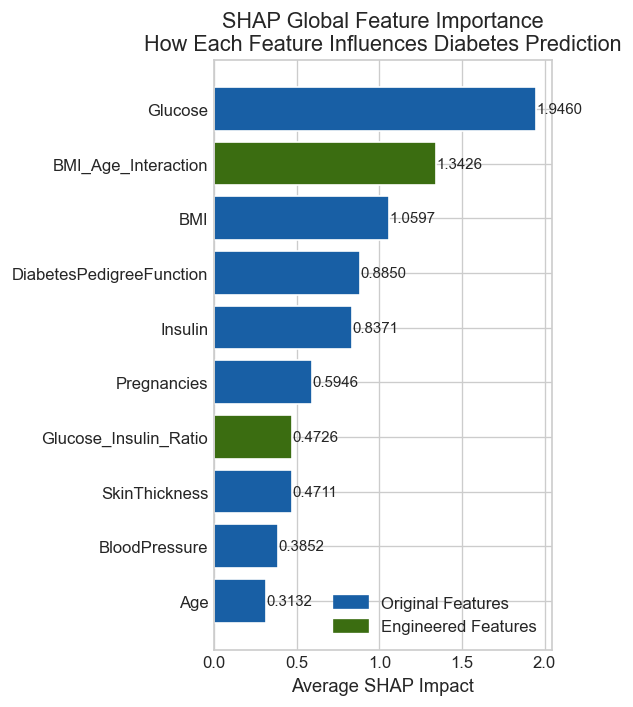

In [81]:
# Calculate average SHAP importance

mean_shap = np.abs(shap_values).mean(axis=0)

# Create feature importance series
shap_imp = pd.Series(
    mean_shap,
    index=COMPLETE_FEATURES
).sort_values()

# Create plot
plt.figure(figsize=(5,6))

# Highlight engineered features in green
bar_colors = [
    COLORS[2] if f in NEW_FEATURES else COLORS[0]
    for f in shap_imp.index
]

# Horizontal bar chart
bars = plt.barh(
    shap_imp.index,
    shap_imp.values,
    color=bar_colors,
    edgecolor="white"
)

# Add value labels
for bar in bars:

    plt.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.4f}",
        va="center",
        fontsize=9
    )

# Axis label
plt.xlabel("Average SHAP Impact")

# Graph title
plt.title(
    "SHAP Global Feature Importance\n"
    "How Each Feature Influences Diabetes Prediction"
)

# Legend
original_patch = mpatches.Patch(
    color=COLORS[0],
    label="Original Features"
)

engineered_patch = mpatches.Patch(
    color=COLORS[2],
    label="Engineered Features"
)

plt.legend(
    handles=[original_patch, engineered_patch]
)
plt.tight_layout()
plt.show()

In [82]:
# Select high-risk patient

xgb_probs = xgb_model.predict_proba(X_test_sclr)[:, 1]

high_risk = np.where(xgb_probs > 0.70)[0]

# Choose patient
if len(high_risk) > 0:

    patient_idx = high_risk[0]

else:

    patient_idx = np.argmax(xgb_probs)

# Patient details
risk_score = xgb_probs[patient_idx]

true_label = y_test[patient_idx]

In [83]:
# Display patient summary
print(f"\nPatient Case Study : Patient #{patient_idx}")

print(
    f"Actual Condition : "
    f"{'Diabetic' if true_label == 1 else 'Non-Diabetic'}"
)

print(f"Predicted Diabetes Risk : {risk_score:.1%}")

# Table heading
print("\n                  Feature Analysis")

print("-" * 55)

print(f"{'Feature':20s} {'Value':10s} {'SHAP':10s}")


Patient Case Study : Patient #0
Actual Condition : Non-Diabetic
Predicted Diabetes Risk : 93.3%

                  Feature Analysis
-------------------------------------------------------
Feature              Value      SHAP      


In [84]:
# Display feature contribution for selected patient
# Table heading
print("\n                  Feature Analysis")

print("-" * 55)

print(f"{'Feature':20s} {'Value':10s} {'SHAP':10s}")

for feat, val, sv in zip(

    COMPLETE_FEATURES,

    X_test_df.iloc[patient_idx].values,

    shap_values[patient_idx]
):

# Effect on diabetes prediction
    effect = (
        "Raises Risk" if sv > 0
        else "Lowers Risk"
    )
# Print feature details
    print(
        f"{feat:25s} "
        f"{val:8.3f}   "
        f"{sv:+.4f}   "
        f"{effect}"
    )


                  Feature Analysis
-------------------------------------------------------
Feature              Value      SHAP      
Pregnancies                  0.961   +0.5483   Raises Risk
Glucose                      1.244   +2.8745   Raises Risk
BloodPressure               -0.689   +0.0335   Raises Risk
SkinThickness               -0.063   -0.8855   Lowers Risk
Insulin                      1.029   +0.6445   Raises Risk
BMI                         -0.736   -0.8504   Lowers Risk
DiabetesPedigreeFunction    -0.556   -0.4459   Lowers Risk
Age                          0.561   -0.6018   Lowers Risk
BMI_Age_Interaction          0.026   +0.7242   Raises Risk
Glucose_Insulin_Ratio       -0.561   -0.1286   Lowers Risk


In [85]:
### Waterfall visualisation of Patient case study:

# Create SHAP explanation object
shap_exp = shap.Explanation(

    values=shap_values[patient_idx],

    base_values=explainer.expected_value,

    data=X_test_df.iloc[patient_idx].values,

    feature_names=COMPLETE_FEATURES
)


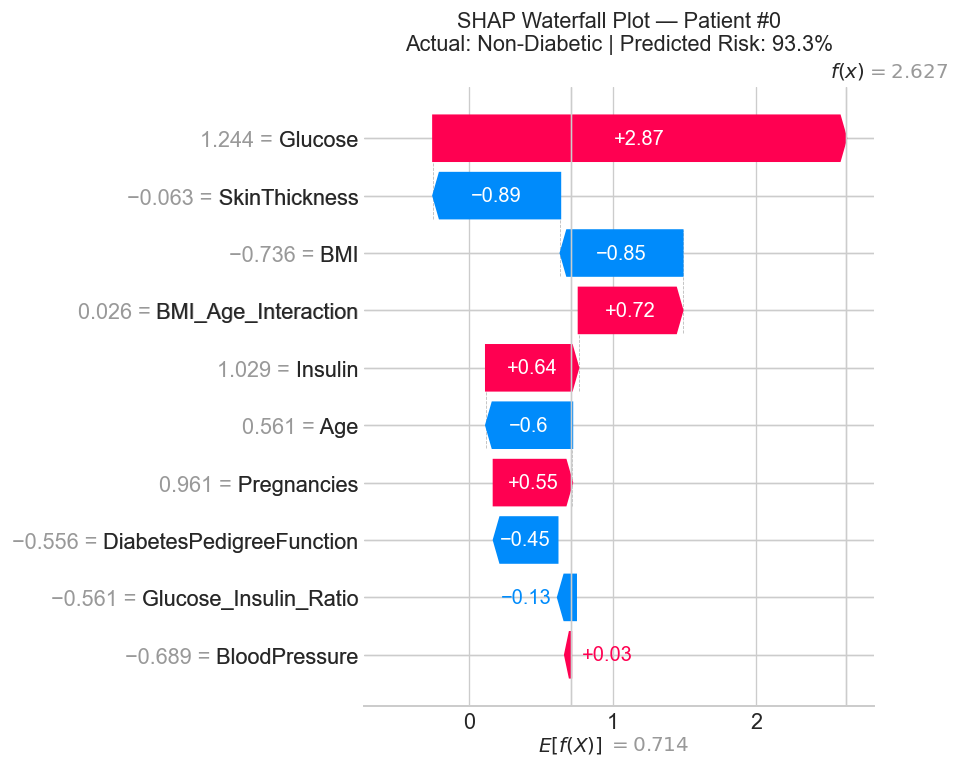

In [86]:
# Create waterfall plot
plt.figure(figsize=(4,6))

shap.waterfall_plot(
    shap_exp,
    show=False
)

# Plot title
plt.title(
    f"SHAP Waterfall Plot — Patient #{patient_idx}\n"
    f"Actual: {'Diabetic' if true_label else 'Non-Diabetic'} | "
    f"Predicted Risk: {risk_score:.1%}"
)
plt.tight_layout()
plt.show()

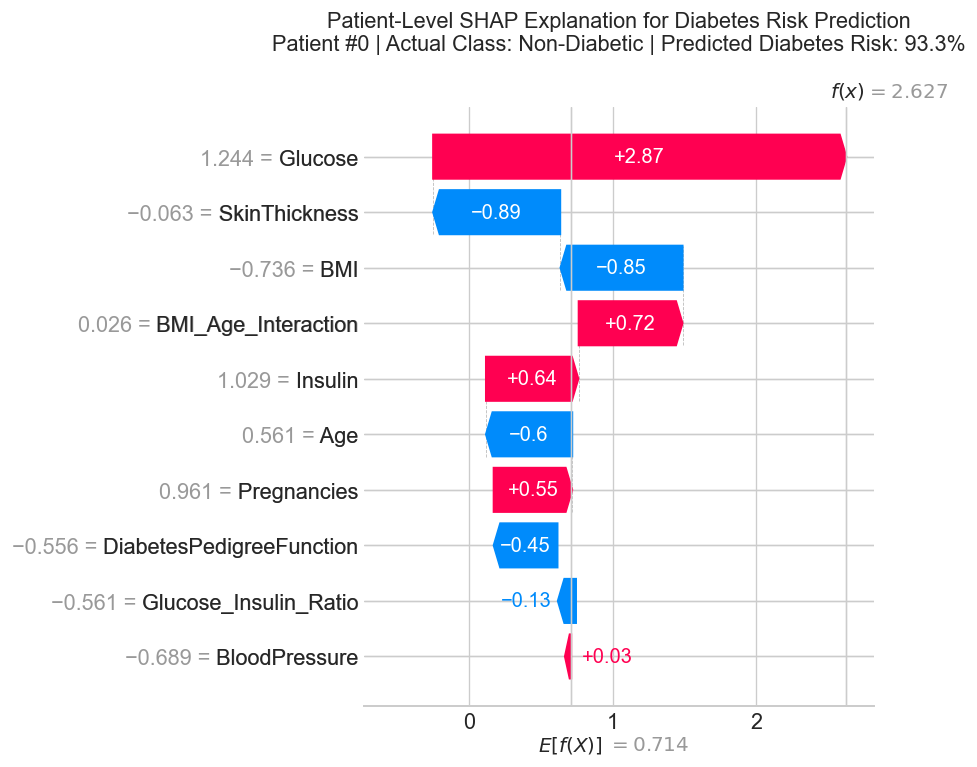

In [87]:
# Create high-quality waterfall plot
plt.figure(figsize=(8, 6))  # Better size for report readability

# Generate SHAP waterfall plot
shap.waterfall_plot(
    shap_exp,
    show=False
)

# Improved professional title
plt.title(
    f"Patient-Level SHAP Explanation for Diabetes Risk Prediction\n"
    f"Patient #{patient_idx} | "
    f"Actual Class: {'Diabetic' if true_label else 'Non-Diabetic'} | "
    f"Predicted Diabetes Risk: {risk_score:.1%}",
    fontsize=13,
    pad=18
)

# Improve spacing
plt.tight_layout()

# Save high-resolution image for university report
plt.savefig(
    "patient_level_shap_waterfall.png",
    dpi=300,
    bbox_inches='tight'
)

# Show plot
plt.show()


<Figure size 720x600 with 0 Axes>

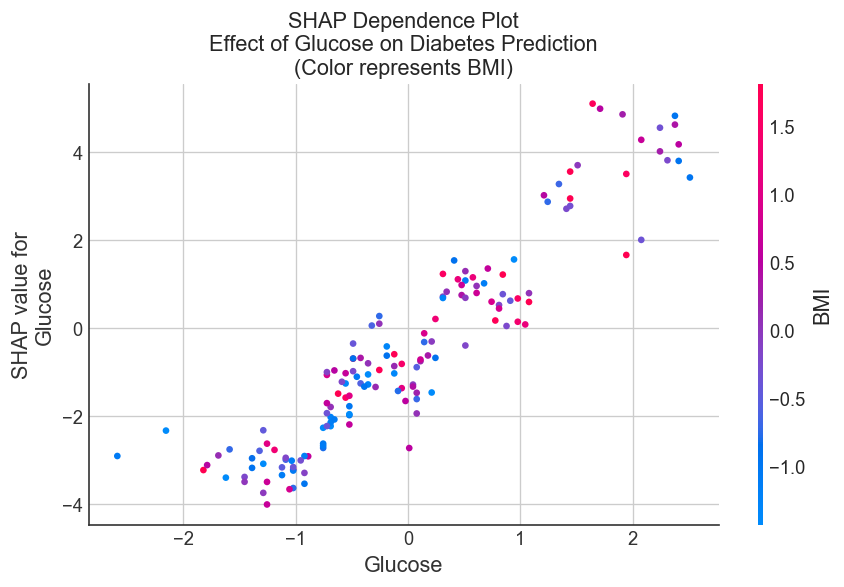

In [88]:
# SHAP Dependence Plot

plt.figure(figsize=(6,5))

# Relationship between Glucose and SHAP value
shap.dependence_plot(
    "Glucose",
    shap_values,
    X_test_df,
    interaction_index="BMI",
    show=False
)

# Graph title
plt.title(
    "SHAP Dependence Plot\n"
    "Effect of Glucose on Diabetes Prediction\n"
    "(Color represents BMI)"
)
plt.tight_layout()
plt.show()

#### CLINICAL CALIBRATION :

In [89]:
## Prediction of  probabilities using original XGBoost model

xgb_raw = trained_models["XGBoost"].predict_proba(
    X_test_sclr
)[:, 1]

# Calculate original Brier Score
brier_raw = brier_score_loss(
    y_test,
    xgb_raw
)

print("Original XGBoost Brier Score")
print(f"Brier Score : {brier_raw:.4f}")

Original XGBoost Brier Score
Brier Score : 0.2085


In [90]:
# Create Platt Scaling model

xgb_platt = CalibratedClassifierCV(

    trained_models["XGBoost"],

    method="sigmoid",

    cv=5
)

# Train calibrated model
xgb_platt.fit(
    X_train_bal,
    y_train_bal
)

# Predict calibrated probabilities
platt_probs = xgb_platt.predict_proba(
    X_test_sclr
)[:, 1]

# Calculate Brier Score
brier_platt = brier_score_loss(
    y_test,
    platt_probs
)
print("Platt Scaling Results")
print(f"Brier Score : {brier_platt:.4f}")

Platt Scaling Results
Brier Score : 0.1776


In [91]:
# Create Isotonic Regression model

xgb_iso = CalibratedClassifierCV(

    trained_models["XGBoost"],

    method="isotonic",

    cv=5
)

# Train calibrated model
xgb_iso.fit(
    X_train_bal,
    y_train_bal
)

# Predict calibrated probabilities
iso_probs = xgb_iso.predict_proba(
    X_test_sclr
)[:, 1]

# Calculate Brier Score
brier_iso = brier_score_loss(
    y_test,
    iso_probs
)

print("Isotonic Regression Results")
print(f"Brier Score : {brier_iso:.4f}")

Isotonic Regression Results
Brier Score : 0.1775


In [92]:
## Final Calibration Comparison

print("\nCalibration Comparison")
print("-" * 45)

print(f"Raw XGBoost      : {brier_raw:.4f}")

print(f"Platt Scaling    : {brier_platt:.4f}")

print(f"Isotonic Method  : {brier_iso:.4f}")

print("\nLower Brier Score = Better Calibration")


Calibration Comparison
---------------------------------------------
Raw XGBoost      : 0.2085
Platt Scaling    : 0.1776
Isotonic Method  : 0.1775

Lower Brier Score = Better Calibration


In [93]:
## Reliability Diagram
## Perfect calibration reference line
for ax in axes:

    ax.plot(
        [0, 1],
        [0, 1],
        "k:",
        linewidth=1.5,
        label="Perfect Calibration"
    )

In [94]:
## Define the calibration models :
## Model probability configurations

configs = [

    ("Raw XGBoost", xgb_raw, COLORS[1], "--"),

    ("Platt Scaling", platt_probs, COLORS[2], "-"),

    ("Isotonic Regression", iso_probs, COLORS[4], "-.")
]

##### Clinical Calibration Analysis:

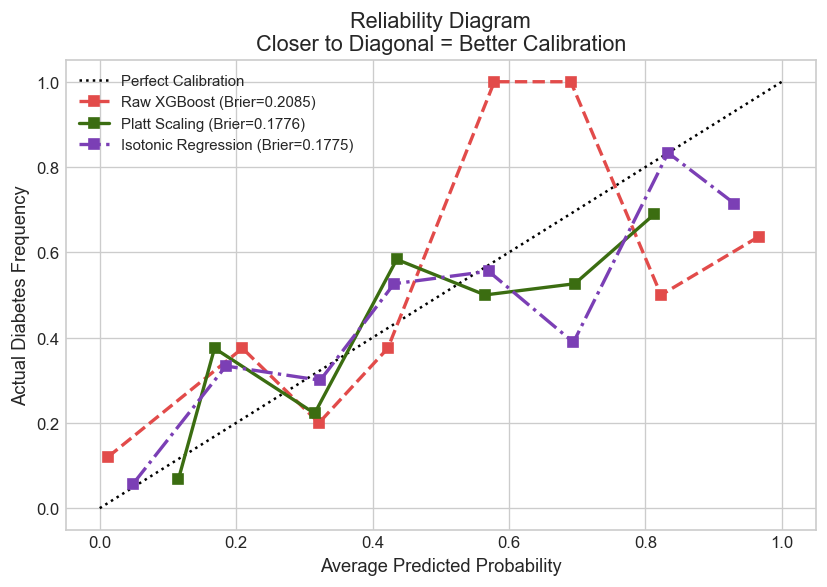

In [95]:
# Reliability Diagram

fig, ax = plt.subplots(figsize=(7, 5))

# Perfect calibration line
plt.plot(
    [0, 1],
    [0, 1],
    "k:",
    linewidth=1.5,
    label="Perfect Calibration"
)

# Plot each model
for name, probs, color, ls in configs:

    frac, mean_p = calibration_curve(
        y_test,
        probs,
        n_bins=8,
        strategy="uniform"
    )

    bs = brier_score_loss(
        y_test,
        probs
    )

    plt.plot(
        mean_p,
        frac,
        marker="s",
        color=color,
        linestyle=ls,
        linewidth=2,
        label=f"{name} (Brier={bs:.4f})"
    )

# Labels and title
plt.xlabel("Average Predicted Probability")

plt.ylabel("Actual Diabetes Frequency")

plt.title(
    "Reliability Diagram\n"
    "Closer to Diagonal = Better Calibration"
)

plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(
    "calibration_reliability_diagram.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

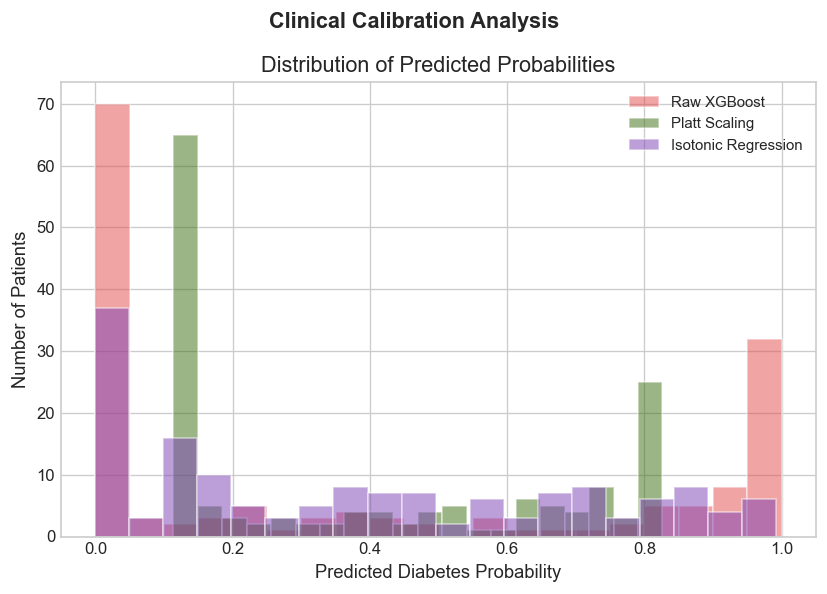

In [96]:
# Distribution of Predicted Probabilities

plt.figure(figsize=(7, 5))

# Histogram for each model
for name, probs, color, _ in configs:

    plt.hist(
        probs,
        bins=20,
        alpha=0.5,
        color=color,
        edgecolor="white",
        label=name
    )

# Labels and title
plt.xlabel("Predicted Diabetes Probability")

plt.ylabel("Number of Patients")

plt.title(
    "Distribution of Predicted Probabilities"
)
plt.suptitle(
    "Clinical Calibration Analysis",
    fontsize=13,
    fontweight="bold"
)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(
    "clinical_calibration_analysispng",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [97]:
## Calibration Summary : 
# Create calibration summary table

cal_table = pd.DataFrame({

    "Method": [
        "Raw XGBoost",
        "Platt Scaling",
        "Isotonic Regression"
    ],

    "Brier Score": [
        round(brier_raw, 4),
        round(brier_platt, 4),
        round(brier_iso, 4)
    ],

    "Improvement": [

        "Baseline",

        f"{(brier_raw - brier_platt) / brier_raw * 100:.1f}% Better",

        f"{(brier_raw - brier_iso) / brier_raw * 100:.1f}% Better"
    ]
})

# Display table
print("\nCalibration Summary Table")

print("-" * 45)

print(cal_table.to_string(index=False))


Calibration Summary Table
---------------------------------------------
             Method  Brier Score  Improvement
        Raw XGBoost       0.2085     Baseline
      Platt Scaling       0.1776 14.8% Better
Isotonic Regression       0.1775 14.9% Better


In [98]:
# Final comparison table

final_tbl = pd.DataFrame([

    {
        "Model"     : name,
        "Accuracy"  : round(res["Accuracy"], 4),
        "Precision" : round(res["Precision"], 4),
        "Recall"    : round(res["Recall"], 4),
        "F1-Score"  : round(res["F1-Score"], 4),
        "AUC-ROC"   : round(res["AUC-ROC"], 4),
        "Brier"     : round(res["Brier"], 4)
    }

    for name, res in results.items()
])

# Display comparison table
print("\n📊 Final Model Comparison")
print("-" * 75)

print(final_tbl.to_string(index=False))


# Find best model
best_model = final_tbl.loc[
    final_tbl["AUC-ROC"].idxmax()
]

print("\n Best Performing Model")
print("-" * 35)

print(f"Model Name : {best_model['Model']}")
print(f"AUC-ROC    : {best_model['AUC-ROC']}")
print(f"Recall     : {best_model['Recall']}")
print(f"F1-Score   : {best_model['F1-Score']}")

print("\n Higher Recall indicates")
print(" better diabetic patient detection after SMOTE balancing.")

# Classification report
print("\n Classification Report — Stacking Classifier")
print("-" * 55)

print(
    classification_report(
        y_test,
        results["Stacking Classifier"]["y_pred"],
        target_names=[
            "Non-Diabetic (0)",
            "Diabetic (1)"
        ]
    )
)


📊 Final Model Comparison
---------------------------------------------------------------------------
              Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC  Brier
Logistic Regression    0.7078     0.5763  0.6296    0.6018   0.7944 0.1877
                SVM    0.7208     0.6000  0.6111    0.6055   0.7906 0.1854
      Random Forest    0.7403     0.6167  0.6852    0.6491   0.8266 0.1641
            XGBoost    0.7662     0.6552  0.7037    0.6786   0.8081 0.2085
           LightGBM    0.7338     0.6102  0.6667    0.6372   0.8078 0.2154
Stacking Classifier    0.7338     0.5915  0.7778    0.6720   0.8270 0.1724

 Best Performing Model
-----------------------------------
Model Name : Stacking Classifier
AUC-ROC    : 0.827
Recall     : 0.7778
F1-Score   : 0.672

 Higher Recall indicates
 better diabetic patient detection after SMOTE balancing.

 Classification Report — Stacking Classifier
-------------------------------------------------------
                  precision    recal

##### Performance Comparison of Machine Learning Models Using Multiple Evaluation Metrics

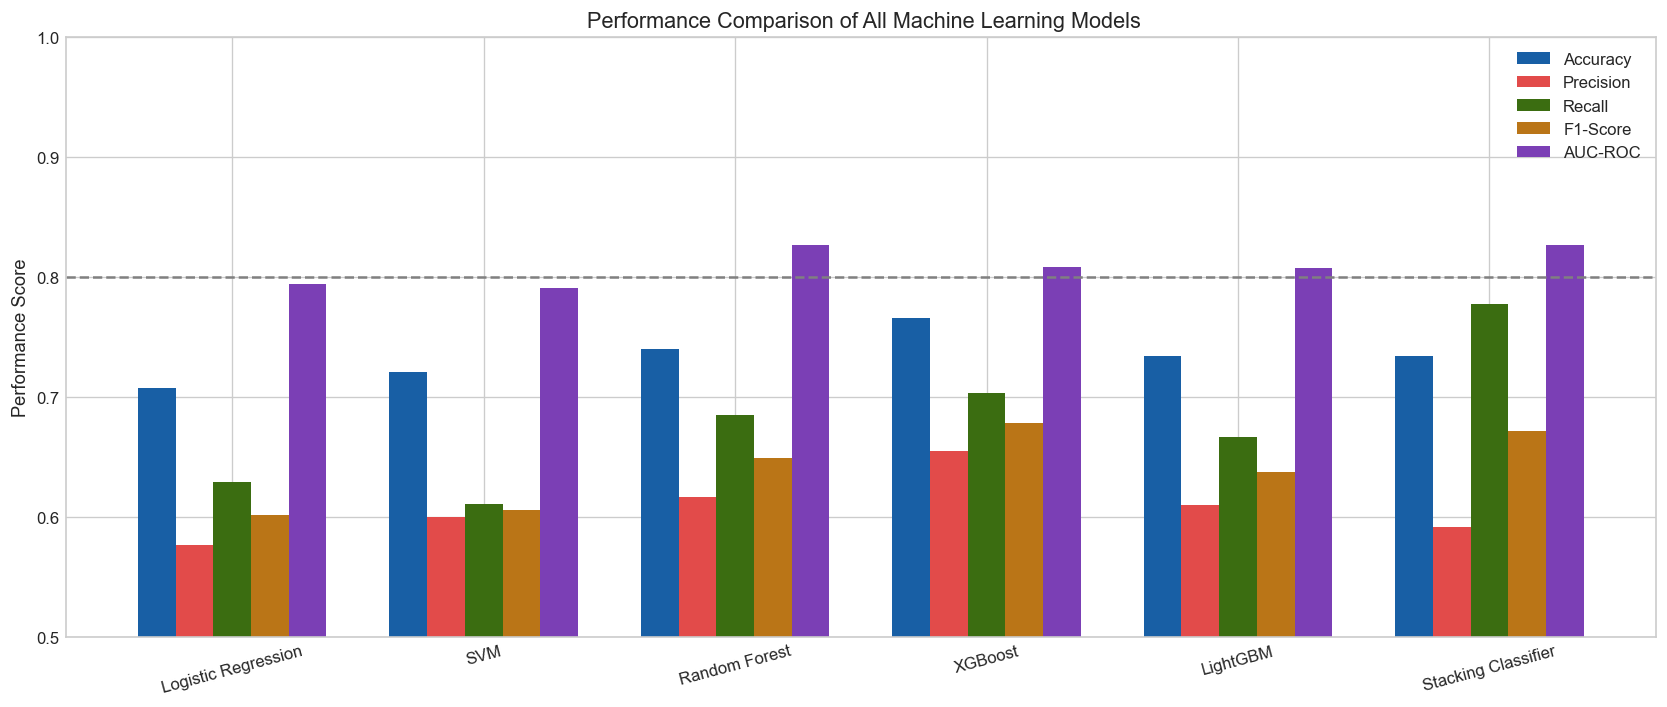

In [99]:
# Metrics to compare
metrics_p = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "AUC-ROC"
]

# Model names
model_list = final_tbl["Model"]

# X-axis positions
x = np.arange(len(model_list))

# Bar width
width = 0.15

# Create figure
plt.figure(figsize=(14, 6))

# Plot each metric
for i, metric in enumerate(metrics_p):

    plt.bar(
        x + i * width,
        final_tbl[metric],
        width=width,
        label=metric,
        color=COLORS[i]
    )

# X-axis labels
plt.xticks( x + width * 2, model_list, rotation=15)

# Labels and title
plt.ylabel("Performance Score")

plt.title(" Performance Comparison of All Machine Learning Models")

# Reference line
plt.axhline(
    0.80,
    linestyle="--",
    color="gray"
)

# Limits
plt.ylim(0.50, 1.00)

# Legend
plt.legend()

plt.tight_layout()
plt.savefig(
    "Performance_comparison_of_ML_models",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### System Testing 

#### Alpha Testing

In [101]:
print("=" * 60)
print("ALPHA TESTING — Internal Development Checks")
print("=" * 60)

alpha_pass = 0
alpha_fail = 0

# AT-1: Dataset check
print("\n[AT-1] Dataset Integrity Check")
try:
    assert df_feature.shape[0] > 0, "Dataset is empty"
    assert df_feature.isnull().sum().sum() == 0, "Missing values found"
    print("PASS: Dataset is clean and loaded correctly")
    alpha_pass += 1
except Exception as e:
    print("FAIL:", e)
    alpha_fail += 1


# AT-2: Feature alignment check
print("\n[AT-2] Feature Alignment Check")
try:
    assert len(COMPLETE_FEATURES) == X_test_sclr.shape[1], "Feature mismatch"
    print("PASS: Feature alignment correct")
    alpha_pass += 1
except Exception as e:
    print("FAIL:", e)
    alpha_fail += 1


# AT-3: Model prediction check
print("\n[AT-3] Model Prediction Check")
try:
    for name, model in trained_models.items():
        preds = model.predict(X_test_sclr)
        probs = model.predict_proba(X_test_sclr)[:, 1]
        assert len(preds) == len(y_test)
        assert probs.min() >= 0 and probs.max() <= 1
        print(f"PASS: {name} working correctly")
    alpha_pass += 1
except Exception as e:
    print("FAIL:", e)
    alpha_fail += 1


print("\nALPHA SUMMARY")
print("Passed:", alpha_pass)
print("Failed:", alpha_fail)

ALPHA TESTING — Internal Development Checks

[AT-1] Dataset Integrity Check
PASS: Dataset is clean and loaded correctly

[AT-2] Feature Alignment Check
PASS: Feature alignment correct

[AT-3] Model Prediction Check
PASS: Logistic Regression working correctly
PASS: SVM working correctly
PASS: Random Forest working correctly
PASS: XGBoost working correctly
PASS: LightGBM working correctly

ALPHA SUMMARY
Passed: 3
Failed: 0


#### Beta Testing

In [105]:
print("=" * 60)
print("BETA TESTING — 5-Fold Cross Validation (STACKED SYSTEM)")
print("=" * 60)

X_full = df_feature[COMPLETE_FEATURES].values
y_full = df_feature[TARGET].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

auc_scores = []
recall_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, y_full), 1):

    # Split data
    X_tr, X_val = X_full[train_idx], X_full[val_idx]
    y_tr, y_val = y_full[train_idx], y_full[val_idx]

    # -----------------------------
    # Step 1: scale fold data
    # -----------------------------
    scaler_fold = StandardScaler()
    X_tr = scaler_fold.fit_transform(X_tr)
    X_val = scaler_fold.transform(X_val)

    # -----------------------------
    # Step 2: train base models
    # -----------------------------
    fold_base_preds_train = np.zeros((X_tr.shape[0], len(base_models)))
    fold_base_preds_val = np.zeros((X_val.shape[0], len(base_models)))

    for i, (name, clf) in enumerate(base_models.items()):

        model = clf.__class__(**clf.get_params())

        model.fit(X_tr, y_tr)

        fold_base_preds_val[:, i] = model.predict_proba(X_val)[:, 1]

    # -----------------------------
    # Step 3: meta-model prediction
    # -----------------------------
    meta_probs = meta_clf.predict_proba(fold_base_preds_val)[:, 1]
    meta_preds = (meta_probs >= 0.5).astype(int)

    # -----------------------------
    # Step 4: metrics
    # -----------------------------
    auc = roc_auc_score(y_val, meta_probs)
    rec = recall_score(y_val, meta_preds)

    auc_scores.append(auc)
    recall_scores.append(rec)

    print(f"Fold {fold}: AUC={auc:.4f}, Recall={rec:.4f}")

# -----------------------------
# FINAL SUMMARY
# -----------------------------
print("\nBETA SUMMARY")
print("-" * 40)
print(f"Mean AUC    : {np.mean(auc_scores):.4f}")
print(f"Mean Recall : {np.mean(recall_scores):.4f}")

BETA TESTING — 5-Fold Cross Validation (STACKED SYSTEM)
Fold 1: AUC=0.8744, Recall=0.8148
Fold 2: AUC=0.8539, Recall=0.6667
Fold 3: AUC=0.8176, Recall=0.7407
Fold 4: AUC=0.8370, Recall=0.6981
Fold 5: AUC=0.7851, Recall=0.7547

BETA SUMMARY
----------------------------------------
Mean AUC    : 0.8336
Mean Recall : 0.7350


#### WHITE-BOX TESTING (XGBOOST + SHAP)

In [103]:
print("=" * 60)
print("WHITE-BOX TESTING — SHAP Analysis (XGBoost)")
print("=" * 60)

wb_model = trained_models["XGBoost"]

wb_explainer = shap.TreeExplainer(wb_model)
wb_shap_values = wb_explainer.shap_values(X_test_df)

mean_shap = np.abs(wb_shap_values).mean(axis=0)

white_box_df = pd.DataFrame({
    "Feature": COMPLETE_FEATURES,
    "SHAP Impact": mean_shap
}).sort_values(by="SHAP Impact", ascending=False)

print(white_box_df)


# CHECK: Glucose importance
print("\n[CHECK] Glucose ranking")
rank = list(white_box_df["Feature"]).index("Glucose") + 1
print("Glucose Rank:", rank)

WHITE-BOX TESTING — SHAP Analysis (XGBoost)
                    Feature  SHAP Impact
1                   Glucose     1.946007
8       BMI_Age_Interaction     1.342599
5                       BMI     1.059700
6  DiabetesPedigreeFunction     0.884977
4                   Insulin     0.837106
0               Pregnancies     0.594650
9     Glucose_Insulin_Ratio     0.472569
3             SkinThickness     0.471053
2             BloodPressure     0.385179
7                       Age     0.313183

[CHECK] Glucose ranking
Glucose Rank: 1


#### BLACK-BOX TESTING (STACKING CLASSIFIER)

In [104]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss
)

print("=" * 60)
print("BLACK-BOX TESTING — STACKED META-LEARNER (meta_clf)")
print("=" * 60)

# -----------------------------
# FINAL STACKED MODEL PREDICTIONS
# -----------------------------
stack_probs = meta_clf.predict_proba(oof_test)[:, 1]
stack_preds = (stack_probs >= 0.5).astype(int)

# -----------------------------
# METRICS
# -----------------------------
bb_results = {
    "Accuracy": accuracy_score(y_test, stack_preds),
    "Precision": precision_score(y_test, stack_preds),
    "Recall": recall_score(y_test, stack_preds),
    "F1-Score": f1_score(y_test, stack_preds),
    "AUC-ROC": roc_auc_score(y_test, stack_probs),
    "Brier Score": brier_score_loss(y_test, stack_probs)
}

# -----------------------------
# DISPLAY RESULTS
# -----------------------------
for metric, value in bb_results.items():
    print(f"{metric:15s}: {value:.4f}")

print("\n" + "-" * 50)
print("FINAL INTERPRETATION")
print("-" * 50)

print("✔ Model Type      : OOF Stacking (Meta-Learner)")
print("✔ Meta Model      : Logistic Regression (meta_clf)")
print("✔ Input Features  : Base model predictions (oof_test)")
print("✔ Output          : Diabetes risk probability")

# Clinical interpretation
if bb_results["Recall"] >= 0.75:
    print("✔ High Recall → Good diabetic detection ability")
else:
    print(" Recall below ideal clinical threshold (risk of missed cases)")

BLACK-BOX TESTING — STACKED META-LEARNER (meta_clf)
Accuracy       : 0.7338
Precision      : 0.5915
Recall         : 0.7778
F1-Score       : 0.6720
AUC-ROC        : 0.8270
Brier Score    : 0.1724

--------------------------------------------------
FINAL INTERPRETATION
--------------------------------------------------
✔ Model Type      : OOF Stacking (Meta-Learner)
✔ Meta Model      : Logistic Regression (meta_clf)
✔ Input Features  : Base model predictions (oof_test)
✔ Output          : Diabetes risk probability
✔ High Recall → Good diabetic detection ability


### Final Summary

In [106]:
final_summary = pd.DataFrame({
    "Test Type": ["Alpha", "Beta", "White-Box", "Black-Box"],

    "Model Used": [
        "All Models (System Check)",
        "Stacking System (Base Models + meta_clf)",
        "XGBoost + SHAP Explainability",
        "Final Stacked Model (meta_clf)"
    ],

    "Status": [
        "PASS" if alpha_fail == 0 else "FAIL",
        "STABLE" if np.mean(auc_scores) > 0.75 else "CHECK",
        "INTERPRETABLE",
        "BEST PERFORMING SYSTEM"
    ],

    "Key Metric": [
        "Pipeline validation completed",
        f"AUC={np.mean(auc_scores):.3f} | Recall={np.mean(recall_scores):.3f}",
        "Feature importance validated via SHAP",
        f"AUC={bb_results['AUC-ROC']:.3f}" if 'bb_results' in globals() else "AUC computed in black-box"
    ]
})

print("\nFINAL TEST SUMMARY")
print("-" * 50)
print(final_summary)


FINAL TEST SUMMARY
--------------------------------------------------
   Test Type                                Model Used  \
0      Alpha                 All Models (System Check)   
1       Beta  Stacking System (Base Models + meta_clf)   
2  White-Box             XGBoost + SHAP Explainability   
3  Black-Box            Final Stacked Model (meta_clf)   

                   Status                             Key Metric  
0                    PASS          Pipeline validation completed  
1                  STABLE               AUC=0.834 | Recall=0.735  
2           INTERPRETABLE  Feature importance validated via SHAP  
3  BEST PERFORMING SYSTEM                              AUC=0.827  
